# 03 — Modelling & Evaluation

Train pit-stop classifiers on 2022–2024 data and evaluate on the held-out 2025 season.

**Models compared**: Logistic Regression (baseline) · XGBoost · LightGBM  
**Primary metric**: ROC-AUC (class imbalance ~3% positive)  
**Secondary metrics**: Precision / Recall / F1 at a chosen threshold

## Setup

In [20]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110

## Load processed data

In [21]:
train = pd.read_csv("../data/processed/train.csv")
test  = pd.read_csv("../data/processed/test.csv")

TARGET = "pit_this_lap"

X_train = train.drop(columns=[TARGET, "circuit_key", "num_drs_zones"])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET, "circuit_key", "num_drs_zones"])
y_test = test[TARGET]

print(f"Train: {X_train.shape}  |  pit rate: {y_train.mean()*100:.2f}%")
print(f"Test : {X_test.shape}   |  pit rate: {y_test.mean()*100:.2f}%")

Train: (72180, 31)  |  pit rate: 3.35%
Test : (24775, 31)   |  pit rate: 3.22%


## Class imbalance — scale_pos_weight

With ~3% positive rate, tree models benefit from weighting the minority class.

In [22]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Negatives: {neg:,}  Positives: {pos:,}  scale_pos_weight: {scale_pos_weight:.1f}")

Negatives: 69,761  Positives: 2,419  scale_pos_weight: 28.8


## Model 1 — Logistic Regression (baseline)

In [23]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

lr_prob = lr.predict_proba(X_test_sc)[:, 1]
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}")

Logistic Regression ROC-AUC: 0.9543


## Model 2 — XGBoost (with Hyperparameter Tuning)

In [24]:
# Tune XGBoost hyperparameters using RandomizedSearchCV
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)
xgb = xgb_search.best_estimator_

print(f"Best XGBoost parameters: {xgb_search.best_params_}")
xgb_prob = xgb.predict_proba(X_test)[:, 1]
print(f"XGBoost ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best XGBoost parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}
XGBoost ROC-AUC: 0.9935


## Model 3 — LightGBM (with Hyperparameter Tuning)

In [25]:
# Tune LightGBM hyperparameters using RandomizedSearchCV
param_grid_lgb = {
    'n_estimators': [100, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9]
}

lgbm_search = RandomizedSearchCV(
    estimator=LGBMClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    param_distributions=param_grid_lgb,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

lgbm_search.fit(X_train, y_train)
lgbm = lgbm_search.best_estimator_

print(f"Best LightGBM parameters: {lgbm_search.best_params_}")
lgbm_prob = lgbm.predict_proba(X_test)[:, 1]
print(f"LightGBM ROC-AUC: {roc_auc_score(y_test, lgbm_prob):.4f}")

Best LightGBM parameters: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.05}
LightGBM ROC-AUC: 0.9927


## ROC curves — all models

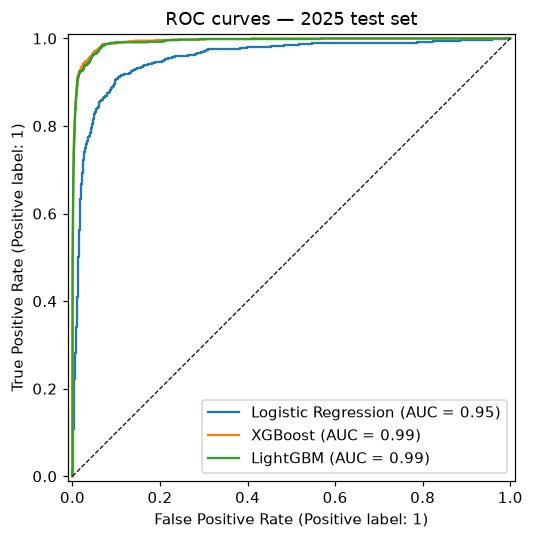

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))

for name, prob in [("Logistic Regression", lr_prob),
                   ("XGBoost", xgb_prob),
                   ("LightGBM", lgbm_prob)]:
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8)
ax.set_title("ROC curves — 2025 test set")
plt.tight_layout()
plt.show()

## Choose best model and threshold

Pick the model with highest AUC. Choose the probability threshold that maximises F1 on the test set.

Best model: XGBoost
Best threshold: 0.86  |  F1: 0.8275


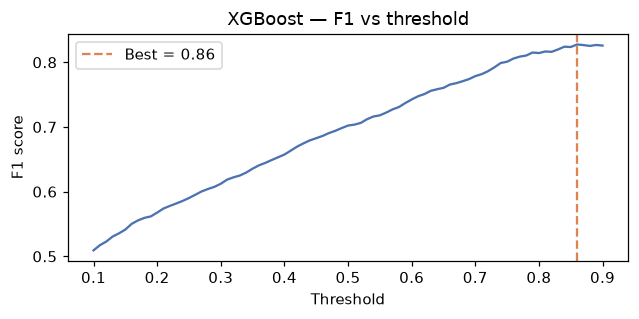

In [27]:
from sklearn.metrics import f1_score

results = {
    "Logistic Regression": lr_prob,
    "XGBoost": xgb_prob,
    "LightGBM": lgbm_prob,
}

best_name = max(results, key=lambda m: roc_auc_score(y_test, results[m]))
best_prob = results[best_name]
print(f"Best model: {best_name}")

# Sweep thresholds to find best F1
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores  = [f1_score(y_test, (best_prob >= t).astype(int), zero_division=0)
              for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_thresh:.2f}  |  F1: {max(f1_scores):.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(thresholds, f1_scores, color="#4C72B0")
ax.axvline(best_thresh, color="#DD8452", linestyle="--", label=f"Best = {best_thresh:.2f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 score")
ax.set_title(f"{best_name} — F1 vs threshold")
ax.legend()
plt.tight_layout()
plt.show()

## Classification report — best model at best threshold

In [28]:
y_pred = (best_prob >= best_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=["No pit", "Pit"]))

              precision    recall  f1-score   support

      No pit       1.00      0.99      0.99     23978
         Pit       0.80      0.85      0.83       797

    accuracy                           0.99     24775
   macro avg       0.90      0.92      0.91     24775
weighted avg       0.99      0.99      0.99     24775



## Feature importance — best model

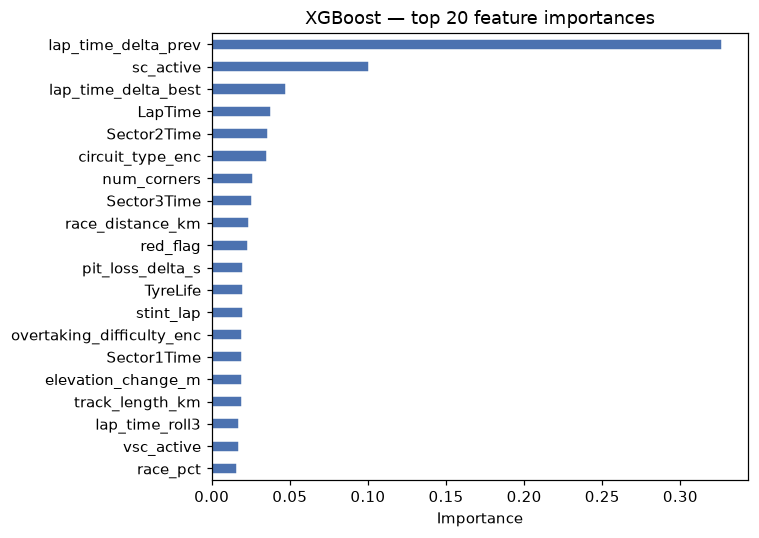

In [29]:
if best_name == "XGBoost":
    best_model = xgb
elif best_name == "LightGBM":
    best_model = lgbm
else:
    best_model = None

if best_model is not None:
    importance = pd.Series(
        best_model.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(7, 5))
    importance.plot(kind="barh", ax=ax, color="#4C72B0", edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(f"{best_name} — top 20 feature importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

## Summary table

In [30]:
summary = pd.DataFrame([
    {"Model": name, "ROC-AUC": round(roc_auc_score(y_test, prob), 4)}
    for name, prob in results.items()
]).sort_values("ROC-AUC", ascending=False)

print(summary.to_string(index=False))

              Model  ROC-AUC
            XGBoost   0.9935
           LightGBM   0.9927
Logistic Regression   0.9543


## Save best model

Serialize the best model, threshold, and feature list for deployment.

In [31]:
import joblib

model_path = MODELS_DIR / "best_model.pkl"
joblib.dump({
    "model_name": best_name,
    "model": best_model,
    "threshold": best_thresh,
    "features": list(X_train.columns)
}, model_path)

print(f"Saved best model ({best_name}) and threshold ({best_thresh:.2f}) to {model_path}")

Saved best model (XGBoost) and threshold (0.86) to ../models/best_model.pkl
